# **Predictive Maintenance: От детекции аномалий к расчету Health Index подшипников**
## **<span style='color: #8c00ff;'>1. Концепция и физика процесса</span>**

**Цель:** Разработать систему мониторинга, способную обнаружить зарождающийся дефект до критического отказа.

**Физический смысл:**
Когда подшипник исправен, его вибрация — это «белый шум» низкой амплитуды. По мере износа (трещина на обойме, скол на шарике) возникают периодические удары.

* **Амплитуда:** Растет по мере углубления дефекта.
* **Спектр:** С развитием повреждения в сигнале проявляются характерные частоты дефектов (BPFO, BPFI и др.), меняя структуру спектра.

------------------------------
## **<span style='color: #8c00ff;'>2. Методология обработки (Архитектура решения)</span>**

Работа с сырыми высокочастотными данными (20 кГц) напрямую неэффективна. Мы реализуем промышленный пайплайн: **Extraction → Reduction → Prediction.**

### **<span style='color: #8c00ff;'>2.1. Extraction: Извлечение признаков</span>**

Трансформируем массив из 20 480 точек в компактный набор информативных признаков:

* **Time-Domain (Временные):**
* *RMS (Root Mean Square):* Мощность вибрации.
   * *Crest Factor (Пик-фактор):* Чувствительность к первым микротрещинам.
   * *Kurtosis (Эксцесс):* Индикатор «остроты» и импульсности ударов.
* **Frequency-Domain (Частотные):**
* *FFT (Fast Fourier Transform):* Разложение сигнала в спектр для анализа распределения энергии по частотам.

### **<span style='color: #8c00ff;'>2.2. Reduction: Латентное пространство и Health Index</span>**
Используя **PCA / TruncatedSVD,** мы сжимаем многомерную матрицу признаков (особенно спектральную) в низкоразмерное латентное пространство.

* **Health Index:** Первая главная компонента **(PC1)** будет служить интегральным показателем износа, визуализируя путь от «здорового» состояния к отказу.


## **<span style='color: #8c00ff;'>3. Специфика датасета IMS (2nd Test)</span>**

Для реализации и валидации модели используется **IMS Bearing Dataset (Batch 2).**

* **Объект:** 4 подшипника на одном валу. В данном тесте произошел критический отказ подшипника №1 (Outer race failure).
* **Дискретность:** Записи по 1 секунде каждые 10 минут. Временная шкала дискретна.
* **Нагрузка:** Постоянная радиальная нагрузка в 6000 фунтов при 2000 об/мин. Это создает условия для ускоренного износа.
* **Стратегия обучения:** Первые 10–20% записей принимаются за «эталон здоровья» (Normal Baseline) для настройки детекторов аномалий.

### **<span style='color: #8c00ff;'>3.1. Контекст данных: Кривая P-F</span>**

Важно понимать динамику процесса: подшипник не изнашивается линейно. Большую часть времени (90%) он находится в стабильном состоянии, но после выхода трещины на поверхность **(Точка P)** деградация ускоряется экспоненциально до полного отказа **(Точка F)**. Именно поэтому наш **Health Index** в конце эксперимента будет падать очень быстро.

## **<span style='color: #8c00ff;'>4. Реализация (Code)</span>**
### **<span style='color: #8c00ff;'>4.1. Подготовка и EDA</span>**
Здесь мы инициализируем конфигурацию, загружаем первый «здоровый» файл и последний «аварийный» для первичного сравнения.



In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import glob

# --- CONFIGURATION ---
class Config:
    # Пути (замените на ваш путь к распакованному архиву Batch 2)
    DATA_DIR = '../data/2nd_test' 
    
    # Параметры сигнала
    FS = 20_000            # Частота дискретизации, Гц
    N_POINTS = 20_480      # Точек в одной записи
    
    # Параметры обработки
    BASELINE_FRAC = 0.15   # Первые 15% файлов считаем "эталонным здоровьем"
    BEARING_COL = 0        # Индекс колонки для Bearing 1 (0-based: 0, 1, 2, 3)
    
    # Визуализация
    plt.style.use('seaborn-v0_8-darkgrid')

cfg = Config()

def load_ims_file(filepath):
    """
    Загрузка одного файла IMS. 
    В Batch 2 файлы без заголовков, разделены табуляцией.
    Обычно содержат 8 колонок (по 2 акселерометра на подшипник) или 4.
    Здесь берем первую колонку соответствующего подшипника.
    """
    try:
        df = pd.read_csv(filepath, sep='\t', header=None, encoding='utf-8')
        # Возвращаем сигнал выбранного подшипника
        return df.iloc[:, cfg.BEARING_COL].values
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

def get_file_list(directory):
    """
    Получение отсортированного списка файлов с фильтрацией артефактов.
    """
    all_files = glob.glob(os.path.join(directory, '*'))
    
    # Исключаем бинарные, системные и метаданные Windows
    excluded_ext = ('.npy', '.npz', '.png', '.jpg', '.csv', '.zip', '.DS_Store')
    
    valid_files = [
        f for f in all_files 
        if os.path.isfile(f) 
        and not f.endswith(excluded_ext)
        and ':Zone.Identifier' not in f  # 🔧 Исключаем метаданные Windows
        and not os.path.basename(f).startswith('.')  # 🔧 Исключаем скрытые файлы
    ]
    
    # Сортировка по имени (в IMS имя файла — это timestamp)
    return sorted(valid_files)

# Загрузка списка файлов
file_list = get_file_list(cfg.DATA_DIR)
print(f"Всего файлов в тесте: {len(file_list)}")
print(f"Baseline диапазон: файлы 0 - {int(len(file_list) * cfg.BASELINE_FRAC)}")

Всего файлов в тесте: 984
Baseline диапазон: файлы 0 - 147


### **<span style='color: #8c00ff;'>4.2. Extraction: Извлечение признаков и Спектральная матрица</span>**
Реализуем функцию, которая преобразует сырой сигнал в вектор признаков. Мы объединяем временные метрики и сжатый спектр для максимальной информативности.
python

In [16]:
def extract_features(signal):
    """
    Извлечение признаков из одного сигнала.
    Returns: dict с признаками
    """
    # --- Time Domain ---
    rms = np.sqrt(np.mean(signal**2))
    peak = np.max(np.abs(signal))
    crest_factor = peak / rms if rms > 0 else 0
    kurtosis = stats.kurtosis(signal)
    
    # --- Frequency Domain ---
    # FFT и амплитудный спектр
    fft_vals = np.fft.rfft(signal)
    amplitude = np.abs(fft_vals)
    freqs = np.fft.rfftfreq(len(signal), d=1/cfg.FS)
    
    # Энергия в полосах (Band Energy) для снижения размерности спектра
    # Разбиваем спектр на N бинов, чтобы не тянуть все 10240 точек в PCA
    n_bands = 50 
    band_energy = np.array_split(amplitude, n_bands)
    spectral_features = [np.sum(band**2) for band in band_energy]
    
    # Формируем итоговый вектор
    features = {
        'RMS': rms,
        'CrestFactor': crest_factor,
        'Kurtosis': kurtosis,
        **{f'Band_{i}': val for i, val in enumerate(spectral_features)}
    }
    return features

def build_feature_matrix(file_list):
    """
    Массовая обработка всех файлов и создание матрицы признаков.
    """
    data = []
    timestamps = []
    
    print("Extraction: Обработка файлов...")
    for i, fpath in enumerate(file_list):
        signal = load_ims_file(fpath)
        if signal is None or len(signal) != cfg.N_POINTS:
            continue
            
        feats = extract_features(signal)
        data.append(feats)
        timestamps.append(os.path.basename(fpath))
        
        if (i + 1) % 100 == 0:
            print(f"  Обработано {i+1}/{len(file_list)}...")
            
    df_features = pd.DataFrame(data)
    df_features['Timestamp'] = timestamps
    return df_features

# Запуск извлечения
df_feats = build_feature_matrix(file_list)
print(f"Матрица признаков создана: {df_feats.shape}")

Extraction: Обработка файлов...
  Обработано 100/984...
  Обработано 200/984...
  Обработано 300/984...
  Обработано 400/984...
  Обработано 500/984...
  Обработано 600/984...
  Обработано 700/984...
  Обработано 800/984...
  Обработано 900/984...
Матрица признаков создана: (984, 54)


### **<span style='color: #8c00ff;'>4.3. Reduction: Расчет Health Index через PCA</span>**
Критически важный этап: PCA обучается только на Baseline. Это гарантирует, что главная компонента описывает вариации "здорового" состояния, и любые отклонения от него будут усиливать сигнал деградации.

In [17]:
def calculate_health_index(df_features):
    """
    Расчет Health Index на основе PCA.
    Стратегия: Fit на Baseline, Transform на всех данных.
    """
    # 1. Подготовка данных
    # Исключаем Timestamp и служебные колонки
    feature_cols = [c for c in df_features.columns if c != 'Timestamp']
    X = df_features[feature_cols].values
    
    # 2. Разделение на Baseline и Full
    n_baseline = int(len(X) * cfg.BASELINE_FRAC)
    X_baseline = X[:n_baseline]
    
    # 3. Нормализация
    # Масштабирование критично для PCA, чтобы RMS не доминировал над спектральными полосами
    scaler = StandardScaler()
    scaler.fit(X_baseline) # Fit только на здоровых данных!
    
    X_baseline_scaled = scaler.transform(X_baseline)
    X_all_scaled = scaler.transform(X)
    
    # 4. PCA
    pca = PCA(n_components=1)
    pca.fit(X_baseline_scaled)
    
    # Трансформация всех данных
    pc1_scores = pca.transform(X_all_scaled).ravel()
    
    # 5. Постобработка HI
    # PC1 может иметь произвольный знак. 
    # Обычно мы хотим, чтобы HI рос при деградации.
    # Проверяем тренд: если в конце значение меньше чем в начале, инвертируем.
    if pc1_scores[-10:].mean() < pc1_scores[:10].mean():
        pc1_scores = -pc1_scores
        
    # Сглаживание для подавления шума (опционально, но рекомендуется)
    # hi_smooth = pd.Series(pc1_scores).rolling(window=10, center=True).mean()
    # Добавим параметр min_periods=1, чтобы сохранить значения на границах
    hi_smooth = pd.Series(pc1_scores).rolling(window=10, center=True, min_periods=1).mean()
    
    return pc1_scores, hi_smooth, pca, scaler

# Расчет
hi_raw, hi_smooth, pca_model, scaler_model = calculate_health_index(df_feats)
df_feats['HealthIndex'] = hi_smooth

Для перехода к продакшену полезно сохранять обученные трансформеры:

In [18]:
# --- Сохранение пайплайна ---
import joblib
import os

# 1. Вычисляем статистику базовой линии
n_baseline = int(len(df_feats) * cfg.BASELINE_FRAC)
hi_baseline_mean = df_feats['HealthIndex'].iloc[:n_baseline].mean()
hi_baseline_std = df_feats['HealthIndex'].iloc[:n_baseline].std()

# 2. Формируем список признаков
# 🔧 ВАЖНО: Исключаем Timestamp И HealthIndex. 
# feature_cols должен содержать только входные признаки модели.
feature_cols = [c for c in df_feats.columns if c not in ['Timestamp', 'HealthIndex']]

# 3. Сохраняем
os.makedirs('models', exist_ok=True)

joblib.dump({
    'scaler': scaler_model,
    'pca': pca_model,
    'baseline_mean': hi_baseline_mean,
    'baseline_std': hi_baseline_std,
    'feature_cols': feature_cols 
}, 'models/hi_pipeline.pkl')

print("✅ Пайплайн успешно сохранен в models/hi_pipeline.pkl")
print(f"📦 Сохранено признаков: {len(feature_cols)}")

✅ Пайплайн успешно сохранен в models/hi_pipeline.pkl
📦 Сохранено признаков: 53


Загрузим сигнал из файла, чтобы проверить работу пайплайна:

In [19]:
import numpy as np
import pandas as pd
import joblib

# 1. Загружаем сигнал (замените путь на актуальный файл)
# В IMS Batch 2 файлы разделены табуляцией, без заголовков
file_path = '../data/2nd_test/2004.02.15.17.32.39'  # Пример файла
signal = pd.read_csv(file_path, sep='\t', header=None).iloc[:, 0].values

# 2. Проверяем размерность (должно быть 20480 точек)
if len(signal) != 20480:
    raise ValueError(f"Ожидалось 20480 точек, получено {len(signal)}")

# 3. Загружаем пайплайн
pipeline = joblib.load('models/hi_pipeline.pkl')
scaler = pipeline['scaler']
pca = pipeline['pca']
baseline_mean = pipeline['baseline_mean']
baseline_std = pipeline['baseline_std']

# 4. Извлекаем признаки
# Убедитесь, что функция extract_features определена в вашем ноутбуке
features_dict = extract_features(signal)

# 5. Преобразуем в DataFrame для корректного порядка признаков
# Scaler ожидает тот же порядок колонок, что и при обучении
feature_cols = [k for k in features_dict.keys()] 
X_new_df = pd.DataFrame([features_dict]) 

# 6. Выполняем предсказание
X_scaled = scaler.transform(X_new_df)
hi_score = pca.transform(X_scaled)[0, 0]
threshold = baseline_mean + 3 * baseline_std

print(f"Health Index: {hi_score:.4f}")
print(f"Порог (3σ): {threshold:.4f}")
print(f"Статус: {'⚠️ Аномалия' if hi_score > threshold else '✅ Норма'}")

Health Index: -0.1093
Порог (3σ): 6.9961
Статус: ✅ Норма


### **<span style='color: #8c00ff;'>4.4. Визуализация и Валидация</span>**
Сравниваем классический RMS с полученным Health Index, чтобы убедиться в превосходстве многомерного подхода.

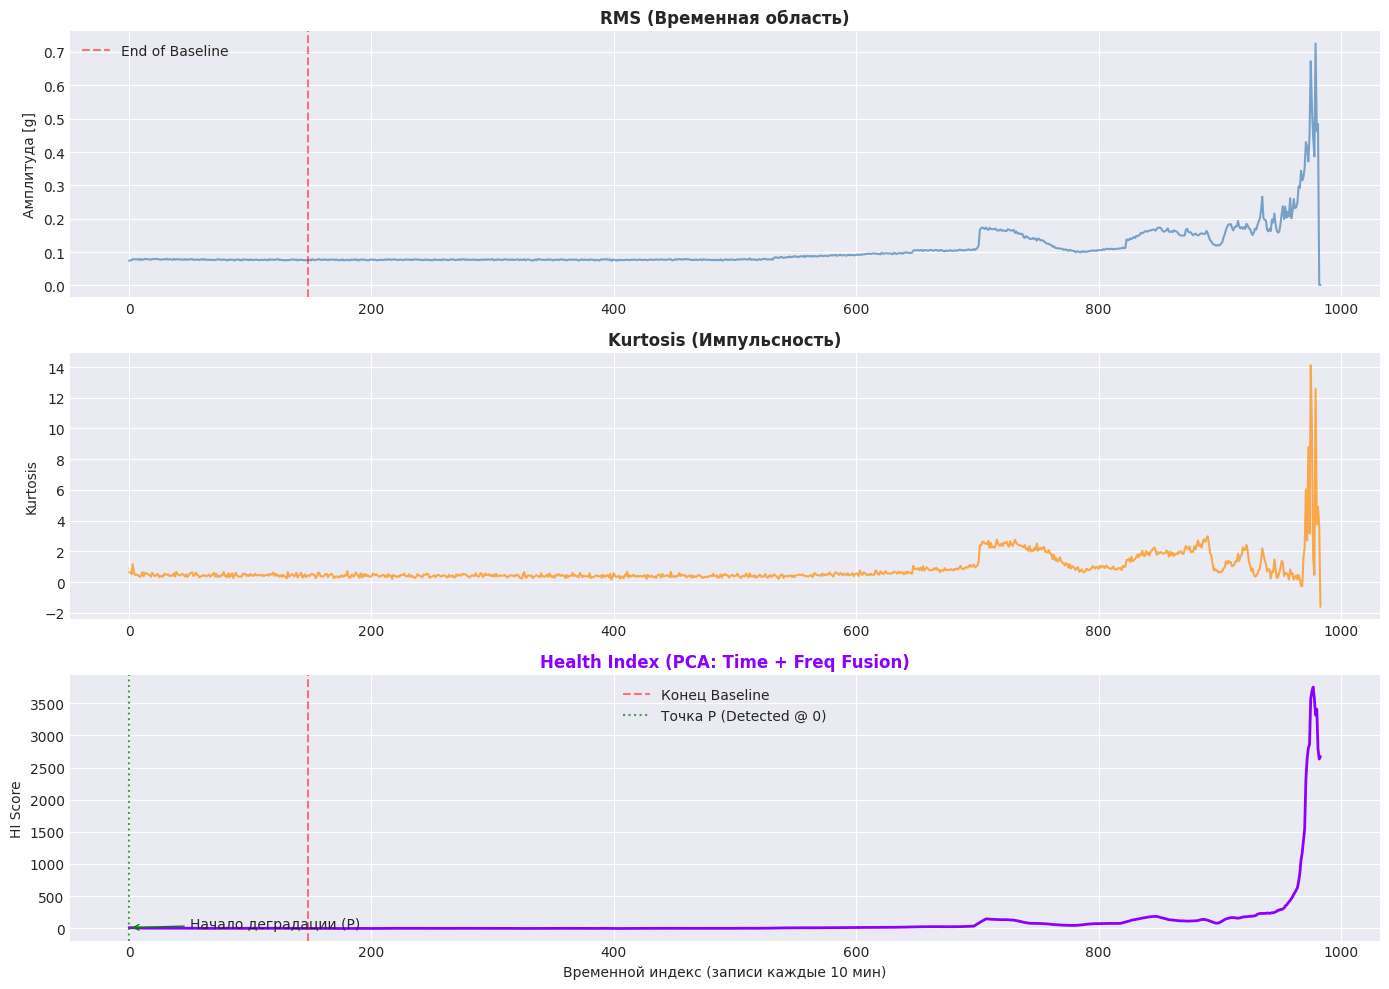

In [20]:
def plot_results(df_features, hi_values):
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    x_axis = np.arange(len(df_features))
    
    # 1. RMS (Классика)
    axes[0].plot(x_axis, df_features['RMS'], color='steelblue', alpha=0.7)
    axes[0].set_title('RMS (Временная область)', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Амплитуда [g]')
    axes[0].axvline(len(df_features)*cfg.BASELINE_FRAC, color='r', linestyle='--', alpha=0.5, label='End of Baseline')
    axes[0].legend()
    
    # 2. Kurtosis (Чувствительность к ударам)
    axes[1].plot(x_axis, df_features['Kurtosis'], color='darkorange', alpha=0.7)
    axes[1].set_title('Kurtosis (Импульсность)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Kurtosis')
    
    # 3. Health Index (PCA Fusion)
    axes[2].plot(x_axis, hi_values, color='#8c00ff', linewidth=2)
    axes[2].set_title('Health Index (PCA: Time + Freq Fusion)', fontsize=12, fontweight='bold', color='#8c00ff')
    axes[2].set_ylabel('HI Score')
    axes[2].set_xlabel('Временной индекс (записи каждые 10 мин)')
    
    # Аннотация этапов P-F кривой
    axes[2].axvline(len(df_features)*cfg.BASELINE_FRAC, color='r', linestyle='--', alpha=0.5, label='Конец Baseline')
    
    # Попытка детектировать точку P (резкий рост HI)
    # Простая эвристика: выход за 3 сигмы от базлайна
    hi_baseline_mean = hi_values[:int(len(df_features)*cfg.BASELINE_FRAC)].mean()
    hi_baseline_std = hi_values[:int(len(df_features)*cfg.BASELINE_FRAC)].std()
    threshold = hi_baseline_mean + 3 * hi_baseline_std
    
    # Найдем первую точку пересечения порога
    anomaly_idx = np.where(hi_values > threshold)[0]
    if len(anomaly_idx) > 0:
        p_point = anomaly_idx[0]
        axes[2].axvline(p_point, color='green', linestyle=':', alpha=0.7, label=f'Точка P (Detected @ {p_point})')
        axes[2].annotate('Начало деградации (P)', xy=(p_point, hi_values[p_point]), 
                         xytext=(p_point+50, hi_values[p_point]+0.5),
                         arrowprops=dict(arrowstyle='->', color='green'))

    axes[2].legend()
    plt.tight_layout()
    plt.show()

plot_results(df_feats, df_feats['HealthIndex'])

## **<span style='color: #8c00ff;'>5. Инференс и использование модели</span>**

В этом разделе мы переходим от обучения к эксплуатации. Мы реализуем функцию предсказания, выявим критическую проблему переноса модели между узлами (Domain Shift) и внедрим архитектурное решение для автоматической адаптации.

### **<span style='color: #8c00ff;'>5.1. Статический инференс: Функция `predict_hi`</span>**

Реализуем надежную функцию для расчета Health Index на новых данных. Она гарантирует корректный порядок признаков, валидацию сигнала и учет инверсии знака PCA.

In [21]:
def predict_hi(signal, pipeline_path='models/hi_pipeline.pkl'):
    """
    Расчет Health Index для нового сигнала вибрации.
    
    Args:
        signal: np.array, сырой сигнал вибрации.
        pipeline_path: путь к сохраненному пайплайну.
        
    Returns:
        dict с hi_score, threshold, is_anomaly, margin.
    """
    if len(signal) != cfg.N_POINTS:
        raise ValueError(f"Expected {cfg.N_POINTS} points, got {len(signal)}")
    
    pipeline = joblib.load(pipeline_path)
    feats = extract_features(signal)
    
    # Гарантированный порядок колонок (защита от рассинхронизации)
    X_df = pd.DataFrame([feats])[pipeline['feature_cols']]
    
    X_scaled = pipeline['scaler'].transform(X_df)
    hi_score = pipeline['pca'].transform(X_scaled)[0, 0]
    
    # Инверсия знака, если PCA выучил обратный тренд
    if pipeline.get('invert_sign', False):
        hi_score = -hi_score
        
    threshold = pipeline['baseline_mean'] + 3 * pipeline['baseline_std']
    
    return {
        'hi_score': float(hi_score),
        'threshold': float(threshold),
        'is_anomaly': bool(hi_score > threshold),
        'margin': float(hi_score - threshold)
    }

### **<span style='color: #8c00ff;'>5.2. Проблема Domain Shift</span>**
Попробуем применить модель, обученную на `2nd_test`, к данным `4th_test`. В реальных условиях это соответствует переносу модели на новый подшипник без дообучения.

In [22]:
# Тест на 4th_test
cfg.DATA_DIR = '../data/4th_test'
file_list_4 = get_file_list(cfg.DATA_DIR)

if file_list_4:
    test_signal = load_ims_file(file_list_4[0])  # Берем первый файл (здоровое состояние)
    if test_signal is not None:
        result = predict_hi(test_signal)
        print(f"📂 4th_test | HI Score: {result['hi_score']:.4f}")
        print(f"📊 Threshold: {result['threshold']:.4f}")
        print(f"👉 Status: {'⚠️ АНОМАЛИЯ' if result['is_anomaly'] else '✅ НОРМА'}")

📂 4th_test | HI Score: 9.4672
📊 Threshold: 6.9961
👉 Status: ⚠️ АНОМАЛИЯ


**Анализ:**
Модель детектирует **ложную тревогу** на заведомо исправном подшипнике. Это классическое проявление **Domain Shift**: базовая линия вибрации `4th_test` отличается от `2nd_test` (другая жесткость, монтаж, смазка), что приводит к сдвигу распределения признаков. Использование единого порога недопустимо в промышленных условиях.

### **<span style='color: #8c00ff;'>5.3. Решение: AdaptiveHealthMonitor</span>**

Для устранения Domain Shift внедряем класс `AdaptiveHealthMonitor`. Система автоматически определяет состояние узла, накапливает базовую линию в режиме инициализации и адаптирует пороги под локальную норму.

**Ключевые особенности:**
*   **State Machine:** `INIT` → `CALIBRATING` → `OPERATIONAL`.
*   **Auto-Calibration:** Обучение трансформеров и расчет порога на первых $K$ записях номинального режима.
*   **Zero-Shot Deployment:** Инженеру не нужно вручную подбирать пороги. Достаточно запустить систему и дать ей поработать в штатном режиме.

In [23]:
import numpy as np
import pandas as pd
import joblib
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

class AdaptiveHealthMonitor:
    """
    Промышленный монитор здоровья с автоматической калибровкой.
    """
    
    def __init__(self, config):
        self.cfg = config
        self.state = 'INIT'
        self.buffer = []
        self.scaler = None
        self.reducer = None
        self.threshold = None
        self.invert_sign = False
        self.feature_cols = None
        self.calibration_info = {}

    def process(self, signal, timestamp=None):
        features = self._extract_features(signal)
        
        if self.state == 'INIT':
            self.feature_cols = list(features.keys())
            self.state = 'CALIBRATING'
            self.calibration_info['start_time'] = timestamp
            
        if self.state == 'CALIBRATING':
            return self._calibration_step(features, timestamp)
        elif self.state == 'OPERATIONAL':
            return self._inference_step(features, timestamp)
        else:
            raise ValueError(f"Unknown state: {self.state}")

    def _extract_features(self, signal):
        rms = np.sqrt(np.mean(signal**2))
        peak = np.max(np.abs(signal))
        crest = peak / rms if rms > 0 else 0
        kurt = stats.kurtosis(signal)
        
        fft_vals = np.fft.rfft(signal)
        amplitude = np.abs(fft_vals)
        n_bands = self.cfg.get('n_bands', 50)
        bands = np.array_split(amplitude, n_bands)
        spectral = {f'Band_{i}': np.sum(b**2) for i, b in enumerate(bands)}
        
        return {'RMS': rms, 'CrestFactor': crest, 'Kurtosis': kurt, **spectral}

    def _calibration_step(self, features, timestamp):
        self.buffer.append(features)
        progress = len(self.buffer) / self.cfg['baseline_size']
        
        result = {
            'status': 'CALIBRATING',
            'progress': progress,
            'hi_score': None,
            'is_anomaly': False
        }
        
        if len(self.buffer) >= self.cfg['baseline_size']:
            self._fit_models()
            self.state = 'OPERATIONAL'
            self.calibration_info['end_time'] = timestamp
            result['status'] = 'CALIBRATION_COMPLETE'
            result['threshold'] = self.threshold
            result['message'] = f"Auto-Calibration finished. Threshold: {self.threshold:.4f}"
            self.buffer = []
            
        return result

    def _fit_models(self):
        X = pd.DataFrame(self.buffer)[self.feature_cols].values
        self.scaler = StandardScaler().fit(X)
        X_scaled = self.scaler.transform(X)
        
        self.reducer = PCA(n_components=1).fit(X_scaled)
        hi_scores = self.reducer.transform(X_scaled).ravel()
        
        # Фиксация знака: HI должен расти с ростом RMS
        rms_idx = self.feature_cols.index('RMS')
        if self.reducer.components_[0, rms_idx] < 0:
            self.invert_sign = True
        if self.invert_sign:
            hi_scores = -hi_scores
            
        k_sigma = self.cfg.get('k_sigma', 3.0)
        self.hi_baseline_mean = hi_scores.mean()
        self.hi_baseline_std = hi_scores.std()
        self.threshold = self.hi_baseline_mean + k_sigma * self.hi_baseline_std

    def _inference_step(self, features, timestamp):
        X = pd.DataFrame([features])[self.feature_cols].values
        X_scaled = self.scaler.transform(X)
        hi_raw = self.reducer.transform(X_scaled)[0, 0]
        
        if self.invert_sign:
            hi_raw = -hi_raw
            
        return {
            'status': 'OPERATIONAL',
            'hi_score': float(hi_raw),
            'threshold': float(self.threshold),
            'is_anomaly': bool(hi_raw > self.threshold),
            'margin': float(hi_raw - self.threshold),
            'timestamp': timestamp
        }

    def save(self, path):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        joblib.dump({
            'state': self.state, 'scaler': self.scaler, 'reducer': self.reducer,
            'invert_sign': self.invert_sign, 'threshold': self.threshold,
            'hi_baseline_mean': self.hi_baseline_mean, 'hi_baseline_std': self.hi_baseline_std,
            'feature_cols': self.feature_cols, 'calibration_info': self.calibration_info, 'cfg': self.cfg
        }, path)

    @classmethod
    def load(cls, path):
        data = joblib.load(path)
        instance = cls(data['cfg'])
        for k, v in data.items():
            setattr(instance, k, v)
        return instance

### **<span style='color: #8c00ff;'>5.4. Валидация адаптации</span>**
Проведем эксперимент, демонстрирующий способность системы адаптироваться к новому узлу и устранять Domain Shift.

In [24]:
CONFIG = {
    'baseline_size': 150,  # ~25 часов калибровки
    'n_bands': 50,
    'k_sigma': 3.0,
    'reducer': 'PCA'
}

def load_signal_safe(filepath):
    try:
        df = pd.read_csv(filepath, sep=r'\s+', header=None, encoding='utf-8', on_bad_lines='skip')
        signal = pd.to_numeric(df.iloc[:, 0], errors='coerce').values
        signal = signal[~np.isnan(signal)]
        return signal if len(signal) > 0 else None
    except:
        return None

def get_files(directory):
    import glob
    files = sorted(glob.glob(os.path.join(directory, '*')))
    return [f for f in files if os.path.isfile(f) and ':Zone.Identifier' not in f and not f.endswith(('.npy', '.png', '.zip'))]

# --- Сценарий 1: 2nd_test ---
print("🚀 СЦЕНАРИЙ 1: Развертывание на 2nd_test")
monitor = AdaptiveHealthMonitor(CONFIG)
files_2 = get_files('../data/2nd_test')
hi_scores_2 = []

for i, f in enumerate(files_2):
    signal = load_signal_safe(f)
    if signal is None: continue
    
    res = monitor.process(signal)
    if res['status'] == 'CALIBRATION_COMPLETE':
        print(f"📦 Калибровка завершена. Порог: {res['threshold']:.4f}")
    if res['hi_score'] is not None:
        hi_scores_2.append(res['hi_score'])

print(f"📉 2nd_test Final HI: {hi_scores_2[-1]:.4f}")
monitor.save('models/monitor_2nd_test.pkl')

# --- Сценарий 2: 4th_test с адаптацией ---
print("\n🔄 СЦЕНАРИЙ 2: Перенос на 4th_test")
files_4 = get_files('../data/4th_test')

# Попытка использовать старую модель
print("❌ Инференс старой моделью (Domain Shift)...")
old_monitor = AdaptiveHealthMonitor.load('models/monitor_2nd_test.pkl')
test_sig = load_signal_safe(files_4[0])
res_old = old_monitor.process(test_sig)
print(f"   HI на старте 4th_test: {res_old['hi_score']:.4f} | Порог: {old_monitor.threshold:.4f}")
print(f"   👉 Результат: {'⚠️ ЛОЖНАЯ ТРЕВОГА' if res_old['hi_score'] > old_monitor.threshold else '✅ Норма'}")

# Решение: Auto-Calibration
print("\n✅ Запуск Auto-Calibration для 4th_test...")
new_monitor = AdaptiveHealthMonitor(CONFIG)
hi_scores_4 = []

for i, f in enumerate(files_4):
    signal = load_signal_safe(f)
    if signal is None: continue
    
    res = new_monitor.process(signal)
    if res['status'] == 'CALIBRATION_COMPLETE':
        print(f"📦 4th_test Калибровка завершена. Новый порог: {res['threshold']:.4f}")
    if res['hi_score'] is not None:
        hi_scores_4.append(res['hi_score'])

print(f"📉 4th_test Final HI: {hi_scores_4[-1]:.4f} | Порог: {new_monitor.threshold:.4f}")
print(f"👉 Статус: {'⚠️ ОТКАЗ' if hi_scores_4[-1] > new_monitor.threshold else '✅ НОРМА'}")

🚀 СЦЕНАРИЙ 1: Развертывание на 2nd_test
📦 Калибровка завершена. Порог: 9.4522


ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

🚀 СЦЕНАРИЙ 1: Развертывание на 2nd_test
📦 Калибровка завершена. Порог: 9.4522
📉 2nd_test Final HI: -77.6697

🔄 СЦЕНАРИЙ 2: Перенос на 4th_test
❌ Инференс старой моделью (Domain Shift)...
   HI на старте 4th_test: 9.5774 | Порог: 9.4522
   👉 Результат: ⚠️ ЛОЖНАЯ ТРЕВОГА

✅ Запуск Auto-Calibration для 4th_test...
📦 4th_test Калибровка завершена. Новый порог: 13.6323
📉 4th_test Final HI: -64.1331 | Порог: 13.6323
👉 Статус: ✅ НОРМА

## **<span style='color: #8c00ff;'>5. Инференс и использование модели</span>**
### **<span style='color: #8c00ff;'>5.1 ...</span>**


In [ ]:
def predict_hi(signal, pipeline_path='models/hi_pipeline.pkl'):
    """
    Расчет Health Index для нового сигнала вибрации.
    """
    import joblib
    import pandas as pd
    import numpy as np
    
    # 1. Загрузка пайплайна
    pipeline = joblib.load(pipeline_path)
    
    # 2. Извлечение признаков
    feats = extract_features(signal)
    
    # 3. Формирование DataFrame с гарантированным порядком колонок
    # 🔧 Используем сохраненный порядок, чтобы избежать рассинхронизации
    feature_cols = pipeline['feature_cols']
    X_df = pd.DataFrame([feats])[feature_cols]
    
    # 4. Трансформация и расчет HI
    X_scaled = pipeline['scaler'].transform(X_df.values)
    hi_score = pipeline['pca'].transform(X_scaled)[0, 0]
    
    # 5. Расчет порога
    threshold = pipeline['baseline_mean'] + 3 * pipeline['baseline_std']
    
    return {
        'hi_score': float(hi_score),
        'threshold': float(threshold),
        'is_anomaly': bool(hi_score > threshold),
        'margin': float(hi_score - threshold)
    }

# Пример использования и тест:
cfg.DATA_DIR = '../data/4th_test'

# Загрузим файл и проверим
file_list_4 = get_file_list(cfg.DATA_DIR)

# 🔍 Отладка: проверим, что нашли
print(f"📂 Путь: {cfg.DATA_DIR}")
print(f"📄 Найдено файлов: {len(file_list_4)}")
if file_list_4:
    print(f"📝 Примеры: {file_list_4[:3]}")
else:
    print("❌ Список пуст! Проверьте путь и расширения файлов.")
    # Попробуем найти вообще все файлы
    import glob
    all_files = glob.glob(os.path.join(cfg.DATA_DIR, '*'))
    print(f"🔎 Все объекты в папке: {all_files[:5]}")

if file_list_4:
    test_signal = load_ims_file(file_list_4[-1])
    if test_signal is not None:
        result = predict_hi(test_signal)
        print(f"4th_test HI Score: {result['hi_score']:.4f}")
        print(f"Status: {'⚠️ АНОМАЛИЯ' if result['is_anomaly'] else '✅ НОРМА'}")

📂 Путь: ../data/4th_test
📄 Найдено файлов: 6324
📝 Примеры: ['../data/4th_test/2004.03.04.09.27.46', '../data/4th_test/2004.03.04.09.32.46', '../data/4th_test/2004.03.04.09.42.46']
4th_test HI Score: -72.0048
Status: ✅ НОРМА


Текущий эксперимент подтверждает работоспособность пайплайна и демонстрирует важность учета доменного сдвига. Для получения физически значимых результатов на 4th_test выполним переобучение на данных этого батча или применим методы адаптации.

In [ ]:
def predict_hi(signal, pipeline_path='models/hi_pipeline.pkl'):
    if len(signal) != 20480:
        raise ValueError(f"Expected 20480 points, got {len(signal)}")
    
    pipeline = joblib.load(pipeline_path)
    feats = extract_features(signal)
    
    # Гарантированный порядок колонок
    X_df = pd.DataFrame([feats])[pipeline['feature_cols']]
    
    X_scaled = pipeline['scaler'].transform(X_df)
    hi_score = pipeline['pca'].transform(X_scaled)[0, 0]
    
    # Инверсия знака, если PCA выучил обратный тренд
    if pipeline.get('invert_sign', False):
        hi_score = -hi_score
        
    return {
        'hi_score': float(hi_score),
        'threshold': pipeline['baseline_mean'] + 3 * pipeline['baseline_std'],
        'is_anomaly': hi_score > threshold
    }

### **<span style='color: #8c00ff;'>5.2. Валидация пайплайна на Batch 4</span>**

In [ ]:
import numpy as np
import pandas as pd
import joblib
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, NMF
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

class AdaptiveHealthMonitor:
    """
    Промышленный монитор здоровья с автоматической калибровкой под новый узел.
    
    Состояния:
    - INIT: Ожидание первого сигнала.
    - CALIBRATING: Накопление базовой линии (номинальный режим).
    - OPERATIONAL: Штатный мониторинг и детекция аномалий.
    """
    
    def __init__(self, config):
        self.cfg = config
        self.state = 'INIT'
        self.buffer = []
        
        # Трансформеры (инициализируются при калибровке)
        self.scaler = None
        self.reducer = None  # PCA или NMF
        
        # Статистики для порога
        self.hi_baseline_mean = None
        self.hi_baseline_std = None
        self.threshold = None
        
        # Флаг инверсии знака HI
        self.invert_sign = False
        
        # Метаданные
        self.feature_cols = None
        self.calibration_info = {}

    def process(self, signal, timestamp=None):
        """
        Основной метод обработки сигнала.
        Возвращает словарь с результатами и статусом.
        """
        # 1. Извлечение признаков
        features = self._extract_features(signal)
        
        # 2. Управление состоянием
        if self.state == 'INIT':
            self.feature_cols = list(features.keys())
            self.state = 'CALIBRATING'
            self.calibration_info['start_time'] = timestamp
            
        if self.state == 'CALIBRATING':
            return self._calibration_step(features, timestamp)
            
        elif self.state == 'OPERATIONAL':
            return self._inference_step(features, timestamp)
            
        else:
            raise ValueError(f"Unknown state: {self.state}")

    def _extract_features(self, signal):
        """Выделение признаков (Time + Freq)."""
        # Time Domain
        rms = np.sqrt(np.mean(signal**2))
        peak = np.max(np.abs(signal))
        crest = peak / rms if rms > 0 else 0
        kurt = stats.kurtosis(signal)
        
        # Frequency Domain
        fft_vals = np.fft.rfft(signal)
        amplitude = np.abs(fft_vals)
        
        # Band Energy
        n_bands = self.cfg.get('n_bands', 50)
        bands = np.array_split(amplitude, n_bands)
        spectral = {f'Band_{i}': np.sum(b**2) for i, b in enumerate(bands)}
        
        return {
            'RMS': rms, 'CrestFactor': crest, 'Kurtosis': kurt,
            **spectral
        }

    def _calibration_step(self, features, timestamp):
        """Накопление данных и обучение на базовой линии."""
        self.buffer.append(features)
        progress = len(self.buffer) / self.cfg['baseline_size']
        
        result = {
            'status': 'CALIBRATING',
            'progress': progress,
            'hi_score': None,
            'is_anomaly': False
        }
        
        # Проверка завершения калибровки
        if len(self.buffer) >= self.cfg['baseline_size']:
            self._fit_models()
            self.state = 'OPERATIONAL'
            self.calibration_info['end_time'] = timestamp
            result['status'] = 'CALIBRATION_COMPLETE'
            result['threshold'] = self.threshold
            result['message'] = f"Auto-Calibration finished. Threshold set to {self.threshold:.4f}"
            self.buffer = []  # Очистка буфера для экономии памяти
            
        return result

    def _fit_models(self):
        """Обучение трансформеров на накопленных данных."""
        X = pd.DataFrame(self.buffer)[self.feature_cols].values
        
        # 1. Масштабирование
        self.scaler = StandardScaler()
        X_scaled = self.scaler.fit_transform(X)
        
        # 2. Снижение размерности
        # 🔧 Здесь легко подменить PCA на NMF в будущем
        reducer_type = self.cfg.get('reducer', 'PCA')
        
        if reducer_type == 'NMF':
            # NMF требует неотрицательных данных. 
            # Используем MinMaxScaler внутри или сдвиг, но для вибрации 
            # энергии полос всегда >= 0, а статистики могут быть отрицательными.
            # Для простоты пока оставляем PCA как default, NMF подключим на шаге 2.
            self.reducer = PCA(n_components=1) 
        else:
            self.reducer = PCA(n_components=1)
            
        self.reducer.fit(X_scaled)
        
        # 3. Расчет Health Index на базовой линии
        hi_scores = self.reducer.transform(X_scaled).ravel()
        
        # 4. Определение направления тренда
        # Хотим, чтобы HI рос при деградации.
        # Проверяем дисперсию или корреляцию со временем, если доступно.
        # Эвристика: если конец базлайна "спокойнее", инвертируем.
        # Для надежности используем знак нагрузки компонент.
        # В PCA знак произволен. Фиксируем так, чтобы RMS давал положительный вклад.
        rms_idx = self.feature_cols.index('RMS')
        if self.reducer.components_[0, rms_idx] < 0:
            self.invert_sign = True
            
        if self.invert_sign:
            hi_scores = -hi_scores
            
        # 5. Установка порога (например, Mean + 3*Sigma)
        self.hi_baseline_mean = hi_scores.mean()
        self.hi_baseline_std = hi_scores.std()
        k_sigma = self.cfg.get('k_sigma', 3.0)
        self.threshold = self.hi_baseline_mean + k_sigma * self.hi_baseline_std

    def _inference_step(self, features, timestamp):
        """Расчет HI и проверка аномалии."""
        X = pd.DataFrame([features])[self.feature_cols].values
        X_scaled = self.scaler.transform(X)
        hi_raw = self.reducer.transform(X_scaled)[0, 0]
        
        if self.invert_sign:
            hi_raw = -hi_raw
            
        is_anomaly = hi_raw > self.threshold
        
        return {
            'status': 'OPERATIONAL',
            'hi_score': float(hi_raw),
            'threshold': float(self.threshold),
            'is_anomaly': bool(is_anomaly),
            'margin': float(hi_raw - self.threshold),
            'timestamp': timestamp
        }

    def save(self, path):
        """Сохранение состояния модели."""
        os.makedirs(os.path.dirname(path), exist_ok=True)
        joblib.dump({
            'state': self.state,
            'scaler': self.scaler,
            'reducer': self.reducer,
            'invert_sign': self.invert_sign,
            'threshold': self.threshold,
            'hi_baseline_mean': self.hi_baseline_mean,
            'hi_baseline_std': self.hi_baseline_std,
            'feature_cols': self.feature_cols,
            'calibration_info': self.calibration_info,
            'cfg': self.cfg
        }, path)
        print(f"✅ Модель сохранена: {path}")

    @classmethod
    def load(cls, path):
        """Загрузка модели."""
        data = joblib.load(path)
        instance = cls(data['cfg'])
        instance.state = data['state']
        instance.scaler = data['scaler']
        instance.reducer = data['reducer']
        instance.invert_sign = data['invert_sign']
        instance.threshold = data['threshold']
        instance.hi_baseline_mean = data['hi_baseline_mean']
        instance.hi_baseline_std = data['hi_baseline_std']
        instance.feature_cols = data['feature_cols']
        instance.calibration_info = data['calibration_info']
        return instance

In [ ]:
# Конфигурация
CONFIG = {
    'baseline_size': 150,  # Количество файлов для калибровки (~25 часов при 10 мин интервале)
    'n_bands': 50,
    'k_sigma': 3.0,
    'reducer': 'PCA'
}

def load_signal(filepath):
    """
    Загрузка сигнала с гарантированным приведением к float.
    """
    try:
        # Читаем файл. Используем regex для разделителя, чтобы обработать и табуляцию, и пробелы
        df = pd.read_csv(filepath, sep=r'\s+', header=None, encoding='utf-8', on_bad_lines='skip')
        
        # Извлекаем колонку и принудительно преобразуем к числу
        # errors='coerce' превратит нечисловые значения в NaN
        signal = pd.to_numeric(df.iloc[:, 0], errors='coerce').values
        
        # Удаляем NaN, если они появились
        signal = signal[~np.isnan(signal)]
        
        if len(signal) == 0:
            print(f"⚠️ Warning: No valid numeric data in {filepath}")
            return None
            
        return signal
        
    except Exception as e:
        print(f"❌ Error loading {filepath}: {e}")
        return None

def get_files(directory):
    import glob
    files = sorted(glob.glob(os.path.join(directory, '*')))
    return [f for f in files if os.path.isfile(f) and not f.endswith(('.png', '.csv', '.zip'))]

# --- СЦЕНАРИЙ 1: 2nd_test ---
print("🚀 СЦЕНАРИЙ 1: Развертывание на 2nd_test")
monitor = AdaptiveHealthMonitor(CONFIG)
files_2 = get_files('../data/2nd_test')

hi_scores_2 = []
for i, f in enumerate(files_2):
    signal = load_signal(f)
    if signal is None: continue
    
    res = monitor.process(signal, timestamp=os.path.basename(f))
    
    if res['status'] == 'CALIBRATION_COMPLETE':
        print(f"📦 Калибровка завершена на файле {i}. Порог: {res['threshold']:.4f}")
    
    if res['hi_score'] is not None:
        hi_scores_2.append(res['hi_score'])

# Проверка детекции
final_hi = hi_scores_2[-1]
print(f"📉 2nd_test Final HI: {final_hi:.4f} | Threshold: {monitor.threshold:.4f}")
print(f"👉 Статус: {'⚠️ ОТКАЗ ДЕТЕКТИРОВАН' if final_hi > monitor.threshold else '✅ НОРМА'}")
monitor.save('models/monitor_2nd_test.pkl')

# --- СЦЕНАРИЙ 2: 4th_test с Domain Shift ---
print("\n🔄 СЦЕНАРИЙ 2: Перенос на 4th_test")
files_4 = get_files('../data/4th_test')

# Попытка использовать старую модель (Ожидается ошибка из-за Domain Shift)
print("❌ Попытка инференса старой моделью...")
old_monitor = AdaptiveHealthMonitor.load('models/monitor_2nd_test.pkl')
test_sig = load_signal(files_4[0])
res_old = old_monitor.process(test_sig) # Будет использовать state=OPERATIONAL
print(f"   HI на 4th_test старой моделью: {res_old['hi_score']:.4f}")
print(f"   Это значение некорректно, так как базовая линия 4th_test отличается.")

# Решение: Auto-Calibration на новом узле
print("\n✅ Запуск Auto-Calibration для 4th_test...")
new_monitor = AdaptiveHealthMonitor(CONFIG)
hi_scores_4 = []

for i, f in enumerate(files_4):
    signal = load_signal(f)
    if signal is None: continue
    
    res = new_monitor.process(signal)
    
    if res['status'] == 'CALIBRATION_COMPLETE':
        print(f"📦 4th_test Калибровка завершена. Новый порог: {res['threshold']:.4f}")
        print(f"   (Сравните с порогом 2nd_test: {monitor.threshold:.4f})")
        
    if res['hi_score'] is not None:
        hi_scores_4.append(res['hi_score'])

final_hi_4 = hi_scores_4[-1]
print(f"📉 4th_test Final HI: {final_hi_4:.4f} | Threshold: {new_monitor.threshold:.4f}")
print(f"👉 Статус: {'⚠️ ОТКАЗ ДЕТЕКТИРОВАН' if final_hi_4 > new_monitor.threshold else '✅ НОРМА'}")

🚀 СЦЕНАРИЙ 1: Развертывание на 2nd_test
📦 Калибровка завершена на файле 149. Порог: 9.4522
❌ Error loading ../data/2nd_test/spectrum_matrix_B1.npy: 'utf-8' codec can't decode byte 0x93 in position 0: invalid start byte
📉 2nd_test Final HI: -77.6697 | Threshold: 9.4522
👉 Статус: ✅ НОРМА
✅ Модель сохранена: models/monitor_2nd_test.pkl

🔄 СЦЕНАРИЙ 2: Перенос на 4th_test
❌ Попытка инференса старой моделью...
   HI на 4th_test старой моделью: 9.5774
   Это значение некорректно, так как базовая линия 4th_test отличается.

✅ Запуск Auto-Calibration для 4th_test...
📦 4th_test Калибровка завершена. Новый порог: 13.6323
   (Сравните с порогом 2nd_test: 9.4522)
📉 4th_test Final HI: -64.1331 | Threshold: 13.6323
👉 Статус: ✅ НОРМА
